In [4]:
import os
import numpy as np

import matplotlib.pyplot as plt


albedo = plt.imread("albedo.webp")
relighted = plt.imread("relighted.webp")
original = plt.imread("original.jpg")

In [15]:
import cv2 as cv

original = cv.resize(original, (albedo.shape[1], albedo.shape[0]))

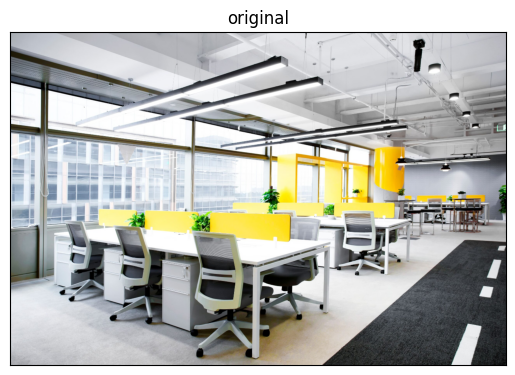

C:\Users\felix\AppData\Local\Temp\ipykernel_6876\4104203670.py:7: RuntimeWarning: divide by zero encountered in divide
  fig = plt.imshow(original / albedo)
C:\Users\felix\AppData\Local\Temp\ipykernel_6876\4104203670.py:7: RuntimeWarning: invalid value encountered in divide
  fig = plt.imshow(original / albedo)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0].


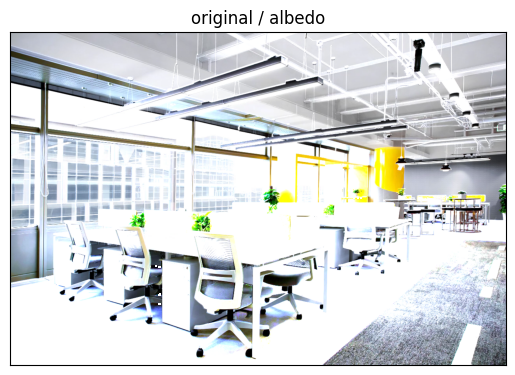

In [36]:
fig = plt.imshow(original)
plt.title("original")
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.show()

fig = plt.imshow(original / albedo)
plt.title("original / albedo")
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)

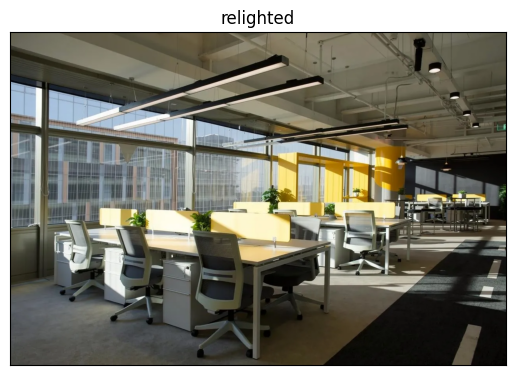

C:\Users\felix\AppData\Local\Temp\ipykernel_6876\192923332.py:7: RuntimeWarning: divide by zero encountered in divide
  fig = plt.imshow(relighted / albedo)
C:\Users\felix\AppData\Local\Temp\ipykernel_6876\192923332.py:7: RuntimeWarning: invalid value encountered in divide
  fig = plt.imshow(relighted / albedo)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..233.0].


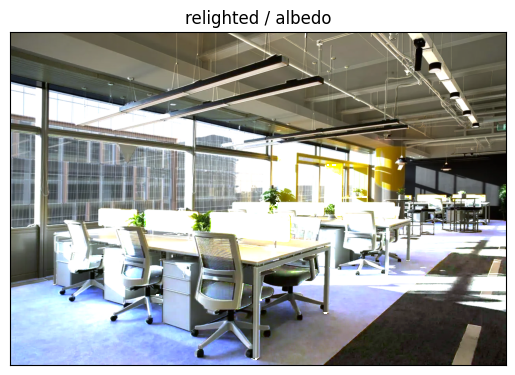

In [35]:
fig = plt.imshow(relighted)
plt.title("relighted")
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.show()

fig = plt.imshow(relighted / albedo)
plt.title("relighted / albedo")
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)

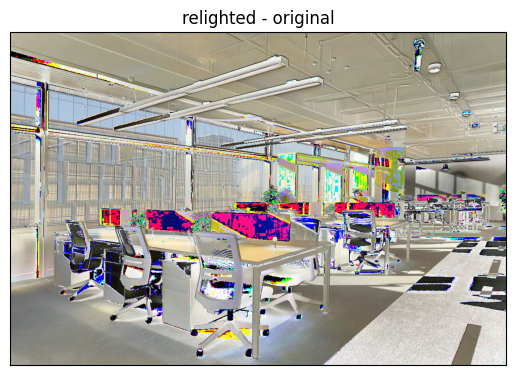

In [32]:
fig = plt.imshow(relighted - original)
plt.title("relighted - original")
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)

In [ ]:
import torch

def tv_loss(x):
    """Isotropic total variation on a [1, C, H, W] tensor."""
    dh = x[..., 1:, :] - x[..., :-1, :]
    dw = x[..., :, 1:] - x[..., :, :-1]
    return (dh ** 2 + 1e-8).sqrt().mean() + (dw ** 2 + 1e-8).sqrt().mean()


def decompose(img1_np, img2_np, n_iter=2000, lr=5e-3,
              lambda_shading_smooth=0.1,
              lambda_albedo_sparse=1.5,
              lambda_consistency=5.0):
    """
    Shared-albedo intrinsic decomposition for two images.

    Model (log space):
        log(I_k) = log_A + log_S_k,  k = 1, 2
        - A  : shared albedo (RGB)
        - S_k: per-image shading (grayscale, broadcast to RGB)

    Losses:
        data          : reconstruction fidelity for both images
        consistency   : log_S1 − log_S2 = mean_c(log_I1 − log_I2)
                        (albedo cancels in the difference, so this
                         directly anchors shadings to observed image diff)
        shading_smooth: TV on each shading map (low λ → shadows allowed)
        albedo_sparse : TV on albedo        (high λ → piece-wise constant)
    """
    eps = 1e-6
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def to_log(arr):
        t = torch.from_numpy(arr.astype("float32") / 255.0).to(device)
        return torch.log(t.clamp(min=eps))  # [H, W, 3]

    log_I1 = to_log(img1_np)
    log_I2 = to_log(img2_np)

    # Initialisation: albedo ≈ geometric mean; shadings ≈ mean-channel residuals
    log_A_init  = (log_I1 + log_I2) / 2
    log_S1_init = (log_I1 - log_A_init).mean(dim=-1, keepdim=True)
    log_S2_init = (log_I2 - log_A_init).mean(dim=-1, keepdim=True)

    log_A  = log_A_init.clone().requires_grad_(True)
    log_S1 = log_S1_init.clone().requires_grad_(True)
    log_S2 = log_S2_init.clone().requires_grad_(True)

    # Target shading difference is fully determined by the image pair
    shading_diff_target = (log_I1 - log_I2).mean(dim=-1, keepdim=True).detach()

    optimizer = torch.optim.Adam([log_A, log_S1, log_S2], lr=lr)

    def to_chw(x):
        return x.permute(2, 0, 1).unsqueeze(0)  # [1, C, H, W]

    history = []
    for i in range(n_iter):
        optimizer.zero_grad()

        recon1 = log_A + log_S1
        recon2 = log_A + log_S2

        loss_data        = ((recon1 - log_I1) ** 2).mean() + ((recon2 - log_I2) ** 2).mean()
        loss_consistency = lambda_consistency   * ((log_S1 - log_S2 - shading_diff_target) ** 2).mean()
        loss_smooth      = lambda_shading_smooth * (tv_loss(to_chw(log_S1)) + tv_loss(to_chw(log_S2)))
        loss_sparse      = lambda_albedo_sparse  *  tv_loss(to_chw(log_A))

        loss = loss_data + loss_consistency + loss_smooth + loss_sparse
        loss.backward()
        optimizer.step()

        if i % 200 == 0:
            history.append(loss.item())
            print(f"[{i:4d}] total={loss.item():.5f}  "
                  f"data={loss_data.item():.5f}  "
                  f"consist={loss_consistency.item():.5f}  "
                  f"smooth={loss_smooth.item():.5f}  "
                  f"sparse={loss_sparse.item():.5f}")

    def to_np_raw(t):
        return t.detach().cpu().numpy()

    albedo   = to_np_raw(torch.exp(log_A))
    shading1 = to_np_raw(torch.exp(log_S1).expand_as(log_I1))
    shading2 = to_np_raw(torch.exp(log_S2).expand_as(log_I2))

    return albedo, shading1, shading2, history


In [ ]:
albedo_opt, shading_orig, shading_relit, history = decompose(original, relighted)


In [ ]:
def show(ax, img, title):
    ax.imshow(img.clip(0, 1))
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

orig_f      = original.astype("float32") / 255.0
relit_f     = relighted.astype("float32") / 255.0
recon_orig  = albedo_opt * shading_orig   # clip only at display
recon_relit = albedo_opt * shading_relit

show(axes[0, 0], orig_f,         "Original")
show(axes[0, 1], albedo_opt,     "Albedo (shared)")
show(axes[0, 2], shading_orig,   "Shading — original")
show(axes[0, 3], recon_orig,     "Reconstruction — original")

show(axes[1, 0], relit_f,        "Relighted")
show(axes[1, 1], albedo_opt,     "Albedo (shared)")
show(axes[1, 2], shading_relit,  "Shading — relighted")
show(axes[1, 3], recon_relit,    "Reconstruction — relighted")

plt.tight_layout()
plt.show()

# Reconstruction error
err_orig  = np.abs(recon_orig  - orig_f).mean()
err_relit = np.abs(recon_relit - relit_f).mean()
print(f"MAE original: {err_orig:.4f}   MAE relighted: {err_relit:.4f}")

# Loss curve
plt.figure(figsize=(6, 3))
plt.plot(range(0, len(history) * 200, 200), history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Total loss")
plt.title("Optimisation loss")
plt.tight_layout()
plt.show()
